# Splitting a polysemantic SPD component — step by step

This notebook walks the **splitting** half of dynamic decomposition for an SPD model, from
loading trained component weights to sweeping the penalty exponent `p`. Every training-objective
formula is **imported from the `spd` repo (v1)** — `calc_causal_importances`,
`calc_stochastic_masks`, `calc_masked_recon_loss`, `calc_masked_recon_layerwise_loss`,
`calc_importance_minimality_loss`, `calc_faithfulness_loss` — so there is exactly one source of
truth for the SPD losses. The notebook only adds what the paper doesn't have: the split surgery,
the per-feature footprint metric, and the outcome analysis.

**The idea.** A trained SPD decomposition with too few components (e.g. C=20 for a 40-feature
TMS model) is *forced* to pack several features into single rank-1 components — they become
**polysemantic**. We take one such component and **split** it into two, then continue training
and watch what happens:

- **CARVE** — the two children specialise to different features (each active only when *its*
  feature fires). This happens when the polysemanticity is *reducible*.
- **COLLAPSE** — one child dies, or they stay redundant. This happens when the features are
  genuinely superposed (irreducible), so there is nothing to separate.

**What drives which?** Two forces act after a split:
1. the **reconstruction losses**, which *want* two specialists when the crammed features fire on
   separable inputs (this is what actually carves);
2. the **importance-minimality penalty** `sum_c g_c^p`, whose exponent `p` decides what happens
   to *redundant* capacity — concave `p<1` prunes a redundant child (collapse to the honest
   count), convex `p>=1` lets it linger.

We sweep `p` to see both effects directly.


## 1. Config

All thresholds live here and **nowhere else** — in particular there is a single `ALIVE_THRESH`
used by the LIVE filter, the outcome classifier, and the recursive-loop history (a previous
version used 0.02 in one place and 0.05 in another). The loss coefficients replicate the values
from the run's `final_config.yaml` (also encoded in the checkpoint directory name:
`stochrecon1.00e+00_stochreconlayer1.00e+00_..._impmin1.00e-04`).

In [4]:
import torch, copy, math
import numpy as np
import matplotlib.pyplot as plt
torch.set_grad_enabled(True)

CKPT_PATH   = "spd/experiments/tms/out/nmasks1_stochrecon1.00e+00_stochreconlayer1.00e+00_p2.00e+00_impmin1.00e-04_C2_sd3_lr1.00e-03_bs4096_ft40_hid10hid-layers0_20260706_005755_990/model_40000.pth"
FEATURE_LAYER = "linear1"          # the reading layer (its input basis == feature basis in TMS)
P_VALUES    = [0.7, 0.9, 1.0, 2.0] # penalty exponents to sweep for the split
RETRAIN_STEPS = 2000               # continue-training steps after each split
LR          = 5e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- Loss coefficients: match spd's TMS config / the run name of CKPT_PATH ---
# (faithfulness_coeff=1.0, stochastic_recon_coeff=1.0, stochastic_recon_layerwise_coeff=1.0;
#  recon_coeff and recon_layerwise_coeff are null in the config and therefore omitted here.)
FAITHFULNESS_COEFF          = 1.0
STOCH_RECON_COEFF           = 1.0
STOCH_RECON_LAYERWISE_COEFF = 1.0
IMPORTANCE_MINIMALITY_COEFF = 2e-5 # training used 1e-4; splits need less -- above the death
                                   # threshold the penalty kills the children (see sweep)
N_MASK_SAMPLES = 1                 # nmasks1 in the run name

# --- Split-retrain protections ---
SPLIT_MODE  = "dummy"          # "partition" (carve-capable) | "split" (50/50 writer) | "duplicate"
FREEZE_OTHERS   = True             # freeze all components EXCEPT the two children during split-retrain
MINIMALITY_WARMUP = 0.2            # ramp the minimality coeff 0 -> target over the first 30% of steps
MONITOR_SPLIT = True               # print child active-rate trajectory during retrain

# --- Thresholds (single source of truth; used consistently everywhere below) ---
TAU             = 0.1              # gate on/off threshold for activation stats
ALIVE_THRESH    = 0.02             # a component/child is ALIVE if active_rate > this (only threshold)
MIN_WNORM_FRAC  = 0.15             # LIVE filter: and carry > this fraction of the max weight-norm
CARVE_OVERLAP_MAX   = 0.15         # CARVE label: children's active-input overlap must be below this
PARTIAL_OVERLAP_MAX = 0.3         # PARTIAL CARVE label: overlap bound (looser; feats reduction decides)
FEATS_REDUCED_FRAC  = 0.7          # PARTIAL CARVE label: max child feats_served < this * parent
MONO_CONC           = 0.8          # CARVE label: each child's read concentration must exceed this
print("device:", DEVICE)

device: cpu


## 2. Helpers — imported from `spd`, plus thin adapters

`calc_causal_importances` returns **two versions of the gate output** for each layer, exactly as
in `spd.run_spd`:

- `ci` = `lower_leaky_relu(gate_output)` — clamped at 1 (leaky below 0). This parameterizes the
  **stochastic masks** `m = ci + (1-ci)·U`, which must live in ~[0,1] to be valid ablation levels.
- `ci_upper_leaky` = `upper_leaky_relu(gate_output)` — relu below 0, leaky *above* 1. This feeds
  the **importance-minimality** penalty: the lower/clamped version would give a saturated gate
  (raw output ≥ 1) zero gradient so the penalty could never pull it down, and its negative values
  raised to a fractional `p` would be NaN. Same gate, two nonlinearities, two jobs.

`sample_batch` reproduces the TMS data distribution of spd's `SparseFeatureDataset`
(`at_least_zero_active`): each feature independently active with probability `p`, magnitude
Uniform[0,1].

In [5]:
# Everything loss- and gate-related is imported from the spd repo (v1) -- the notebook adds
# no formulas of its own for the training objective.
from torch import nn
from spd.models.components import Gate, GateMLP
from spd.models.component_model import ComponentModel
from spd.models.component_utils import calc_causal_importances, calc_stochastic_masks
from spd.losses import (calc_faithfulness_loss, calc_masked_recon_loss,
                        calc_masked_recon_layerwise_loss, calc_importance_minimality_loss)

def module_maps(cm):
    """Real-named views of spd's ModuleDicts (spd stores '.' as '-' in keys)."""
    comps = {k.removeprefix("components.").replace("-", "."): v for k, v in cm.components.items()}
    gates = {k.removeprefix("gates.").replace("-", "."): v for k, v in cm.gates.items()}
    As    = {n: c.A for n, c in comps.items()}
    return comps, gates, As

def n_decomposed_params(cm):
    """Total parameter count of the decomposed target matrices (spd's faithfulness normalizer)."""
    comps, _, _ = module_maps(cm)
    return sum(cm.model.get_submodule(n).weight.numel() for n in comps)

def causal_importances(cm, batch):
    """One target forward -> (ci, ci_upper_leaky, target_out), via spd's calc_causal_importances.
    ci (lower-leaky, clamped at 1) parameterizes the stochastic masks; ci_upper_leaky feeds the
    importance-minimality loss -- the same division of labor as spd.run_spd."""
    comps, gates, As = module_maps(cm)
    target_out, pre = cm.forward_with_pre_forward_cache_hooks(batch, module_names=list(comps.keys()))
    ci, ci_up = calc_causal_importances(pre_weight_acts=pre, As=As, gates=gates)
    return ci, ci_up, target_out

def sample_batch(n_features, p, bs=512):
    """Sparse TMS batch: each feature independently active w.p. p with Uniform[0,1] magnitude --
    the same distribution as spd's SparseFeatureDataset with data_generation_type
    'at_least_zero_active' (used by the TMS config), just without the DataLoader machinery."""
    return ((torch.rand(bs, n_features, device=DEVICE) < p).float()
            * torch.rand(bs, n_features, device=DEVICE))

## 3. Load the decomposed ComponentModel

`ComponentModel.from_pretrained(path)` rebuilds the target model from the run's
`final_config.yaml` and loads the component/gate weights; if the wandb reference inside the
config doesn't resolve, we rebuild the target from the sibling `tms.pth` manually. There is
**no demo fallback**: every result below is about the specific decomposition at `CKPT_PATH`,
so a missing checkpoint raises instead of silently substituting different data.

In [6]:
import os, yaml

def load_componentmodel():
    """Load the decomposed ComponentModel from CKPT_PATH. No demo fallback: if the checkpoint
    is missing this raises, because every result below is about that specific decomposition."""
    if not os.path.exists(CKPT_PATH):
        raise FileNotFoundError(
            f"CKPT_PATH not found: {CKPT_PATH}\n"
            "Edit CKPT_PATH to point at your model_40000.pth (this notebook has no demo mode).")
    try:                                  # standard path (works when pretrained_model_path resolves)
        cm, config, _ = ComponentModel.from_pretrained(CKPT_PATH); cm.to(DEVICE)
        nf = cm.model.get_submodule(FEATURE_LAYER).weight.shape[1]
        p  = getattr(getattr(config, "task_config", None), "feature_probability", 0.05)
    except Exception as e:                 # manual path: rebuild target from sibling tms.pth
        print("from_pretrained fallback:", str(e)[:80])
        d = os.path.dirname(CKPT_PATH)
        cfg = yaml.safe_load(open(os.path.join(d, "final_config.yaml")))
        from spd.experiments.tms.models import TMSModel
        target, _ = TMSModel.from_pretrained(os.path.join(d, "tms.pth"))
        target.eval().requires_grad_(False)
        cm = ComponentModel(target, cfg["target_module_patterns"], C=cfg["C"],
                            n_ci_mlp_neurons=cfg["n_ci_mlp_neurons"],
                            pretrained_model_output_attr=None).to(DEVICE)
        cm.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
        nf = target.config.n_features
        p  = cfg.get("task_config", {}).get("feature_probability", 0.05)
    cm.model.eval().requires_grad_(False)   # the target is data, not a trainable
    return cm, nf, p

## 4. Faithfulness & polysemanticity — what does the decomposition look like?

**Faithfulness** = spd's `calc_faithfulness_loss` (per-element MSE between `sum_c A_c B_c` and
the target weights). **Per-feature footprint** = for component `c`, the per-feature *amplitude*
`e_i = |A[i,c]| · ||B[c,:]||` (the row norms of its rank-1 contribution — a plain norm, **not**
squared energy). From it: `conc = max(e)/sum(e)` (1 ≈ monosemantic) and
`feats_served = (Σe)²/Σe²` (participation ratio; ≈ k for k equally-read features).

Two honesty notes. (1) This metric is **our construction**, not from the SPD paper. (2)
`||B[c,:]||` is constant across features and cancels in both ratios — the metric is purely a
*reader-side* measure, and it is only meaningful because `linear1`'s input basis **is** the
feature basis in TMS. (Threshold guides like `MONO_THRESH` were originally calibrated on the
old squared-energy convention; amplitude PR counts slightly *more* features for uneven
footprints, so treat absolute counts as slightly stricter now.)

**Crucial: filter dead components first.** Concentration is a *ratio*, so a near-zero-energy
component returns a meaningless value that masquerades as "polysemantic". A component is
**LIVE** only if it actually fires (`active_rate > ALIVE_THRESH`) AND carries real weight, and
everything below is restricted to live components.

In [11]:
@torch.no_grad()
def faithfulness_mse(cm):
    """spd's faithfulness loss (per-element MSE between sum-of-components and target weights)."""
    comps, _, _ = module_maps(cm)
    return float(calc_faithfulness_loss(components=comps, target_model=cm.model,
                                        n_params=n_decomposed_params(cm), device=DEVICE))

@torch.no_grad()
def component_stats(cm, layer, n_features, feat_p, tau=TAU, n=8192):
    """Per-component LIVE stats: active rate (gate fires) and weight-norm (real energy)."""
    x = sample_batch(n_features, feat_p, bs=n)
    ci, _, _ = causal_importances(cm, x)
    g = ci[layer]; comp = module_maps(cm)[0][layer]
    active_rate = (g > tau).float().mean(0)
    wnorm = comp.A.norm(dim=0) * comp.B.norm(dim=1)
    return active_rate.detach(), wnorm.detach()

def live_mask(active_rate, wnorm, min_active=None, min_wfrac=MIN_WNORM_FRAC):
    """A component is LIVE only if it fires AND carries real weight. Dead components have
    near-zero energy, so concentration RATIOS are noise-dominated -> meaningless values that
    wrongly look "polysemantic". Filtering them is essential before ranking or splitting."""
    min_active = ALIVE_THRESH if min_active is None else min_active
    return (active_rate > min_active) & (wnorm > min_wfrac * wnorm.max())

@torch.no_grad()
def feature_energy(cm, layer, c):
    """Per-feature energy of component c: e_i = |A[i,c]| * ||B[c,:]||  (the row norms of the
    rank-1 contribution A[:,c] B[c,:]). NOTE this is a plain norm (amplitude), not a squared
    energy. ||B[c,:]|| is a constant across features, so it cancels in every ratio below --
    conc and feats_served are purely READER-side measures. This metric is our construction
    (not from the SPD paper); the paper needs no per-feature footprint, splitting does."""
    comp = module_maps(cm)[0][layer]
    return comp.A[:, c].abs().double() * comp.B[c, :].double().norm()

@torch.no_grad()
def feature_concentration(cm, layer):
    """conc  = e.max()/e.sum()            in (0,1]; 1 = reads one feature (monosemantic)
    nserve = (sum e)^2 / sum(e^2)         participation ratio on AMPLITUDES: ~k for k equal
                                          features. (Amplitude convention -- see feature_energy.)"""
    comp = module_maps(cm)[0][layer]
    conc, nserve = [], []
    for c in range(comp.A.shape[1]):
        e = feature_energy(cm, layer, c)
        tot = e.sum().clamp_min(1e-12)
        conc.append(float(e.max() / tot))
        nserve.append(float(tot ** 2 / (e ** 2).sum().clamp_min(1e-12)))
    return torch.tensor(conc), torch.tensor(nserve)

## 5. The continue-training objective — the full SPD loss

This is now **the complete objective from `spd.run_spd.calculate_losses`**, term for term, with
the coefficients from the run config: faithfulness (1.0) + stochastic recon (1.0) +
**stochastic recon layerwise** (1.0) + importance-minimality (`coeff · Σ ci_upper_leaky^p`).
The layerwise term — masking one decomposed layer at a time while the others use target
weights — was missing from a previous version of this notebook, meaning split-retrains
optimized a *different* objective than the one that produced the checkpoint. Two knobs are ours:
`warmup_frac` ramps the minimality coeff so newborn children can specialize before being taxed,
and `freeze_keep` zeroes gradients for everything except the two children so the other
(redundant-capable) components can't absorb their role and get them killed. A fresh optimizer is
built each call, so it is safe to call right after surgery.

In [12]:
def _freeze_grads_except(cm, keep_layer, keep_idx):
    # Zero grads of every component except columns/rows keep_idx of keep_layer (+ its gate rows).
    # Other decomposed layers are frozen entirely. Call after backward(), before step().
    comps, gates, _ = module_maps(cm)
    for name, comp in comps.items():
        if name == keep_layer:
            for P, axis in [(comp.A, 1), (comp.B, 0)]:
                if P.grad is not None:
                    m = torch.zeros_like(P.grad)
                    if axis == 1: m[:, keep_idx] = 1
                    else: m[keep_idx, :] = 1
                    P.grad *= m
            g = gates[name]
            for nm in ["weight", "bias", "mlp_in", "in_bias", "mlp_out", "out_bias"]:
                P = getattr(g, nm, None)
                if P is not None and P.grad is not None:
                    m = torch.zeros_like(P.grad); m[keep_idx] = 1; P.grad *= m
        else:
            for P in comp.parameters():
                if P.grad is not None: P.grad.zero_()
            for P in gates[name].parameters():
                if P.grad is not None: P.grad.zero_()

@torch.no_grad()
def _active_rate(cm, layer, idx):
    x = sample_batch(N_FEATURES if "N_FEATURES" in globals() else 40,
                     FEAT_P if "FEAT_P" in globals() else 0.05, bs=4096)
    ci, _, _ = causal_importances(cm, x)
    g = ci[layer]
    return [round(float((g[:, i] > TAU).float().mean()), 3) for i in idx]

def continue_train(cm, n_features, feat_p, steps, p_norm,
                   imp_coeff=IMPORTANCE_MINIMALITY_COEFF, lr=LR, n_mask=N_MASK_SAMPLES,
                   log_every=0, freeze_keep=None, warmup_frac=0.0, monitor=None):
    """Continue training with THE spd objective -- every term is spd's own function:
        FAITHFULNESS_COEFF          * calc_faithfulness_loss
      + STOCH_RECON_COEFF           * calc_masked_recon_loss           (over stochastic masks)
      + STOCH_RECON_LAYERWISE_COEFF * calc_masked_recon_layerwise_loss (same masks, one layer at a time)
      + coeff_t                     * calc_importance_minimality_loss  (on ci_upper_leaky, exponent p_norm)
    coeff_t ramps 0 -> imp_coeff over the first warmup_frac of steps (newborn children need time
    to specialize before they are taxed). Fresh optimizer each call: safe after surgery."""
    comps, gates, As = module_maps(cm)
    n_params = n_decomposed_params(cm)
    opt = torch.optim.Adam([q for q in cm.parameters() if q.requires_grad], lr=lr)
    for step in range(steps):
        x = sample_batch(n_features, feat_p)
        ci, ci_up, target_out = causal_importances(cm, x)
        masks_list = calc_stochastic_masks(causal_importances=ci, n_mask_samples=n_mask)
        stoch = torch.zeros((), device=DEVICE)
        for masks in masks_list:
            stoch = stoch + calc_masked_recon_loss(model=cm, batch=x, components=comps,
                                                   masks=masks, target_out=target_out, loss_type="mse")
        stoch = stoch / len(masks_list)
        stoch_lw = calc_masked_recon_layerwise_loss(model=cm, batch=x, device=DEVICE,
                                                    components=comps, masks=masks_list,
                                                    target_out=target_out, loss_type="mse")
        # NOTE: called per layer (mathematically identical to one call -- the loss is additive
        # across layers) because upstream assumes equal C in every layer, which stops being
        # true the moment a split grows one layer's C.
        minim = sum(calc_importance_minimality_loss(ci_upper_leaky={n: u}, pnorm=p_norm)
                    for n, u in ci_up.items())
        faith = calc_faithfulness_loss(components=comps, target_model=cm.model,
                                       n_params=n_params, device=DEVICE)
        coeff_t = imp_coeff * (min(1.0, step / max(int(steps * warmup_frac), 1)) if warmup_frac > 0 else 1.0)
        loss = (FAITHFULNESS_COEFF * faith + STOCH_RECON_COEFF * stoch
                + STOCH_RECON_LAYERWISE_COEFF * stoch_lw + coeff_t * minim)
        opt.zero_grad(); loss.backward()
        if freeze_keep is not None:
            _freeze_grads_except(cm, *freeze_keep)
        opt.step()
        if log_every and (step % log_every == 0 or step == steps - 1):
            print(f"  step {step:5d}  stoch={stoch.item():.5f} lw={stoch_lw.item():.5f} "
                  f"minim={minim.item():.4f} faith={faith.item():.2e} (coeff_t={coeff_t:.1e})")
        if monitor is not None and (step % max(steps // 8, 1) == 0 or step == steps - 1):
            print(f"      [monitor] step {step:5d} child_active={_active_rate(cm, monitor[0], monitor[1])} "
                  f"(coeff_t={coeff_t:.1e} stoch={stoch.item():.4f} faith={faith.item():.2e})")
    return cm

## Load and inspect

faithfulness MSE: 1.008e-01   (low = decomposition reproduces target)
LIVE components: 2/2  -> [0, 1]
LIVE concentration: {0: 0.08, 1: 0.08}
LIVE features-served: {0: 24.3, 1: 23.8}


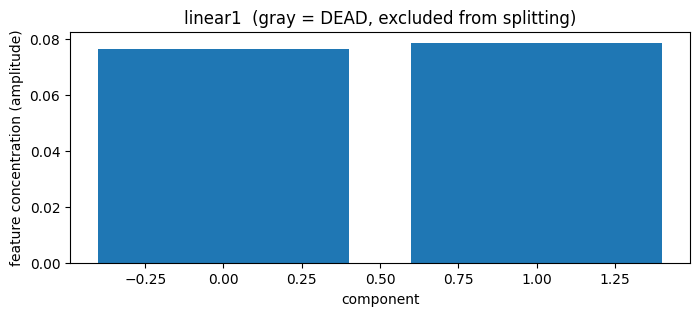

In [13]:
cm, N_FEATURES, FEAT_P = load_componentmodel()

print(f"faithfulness MSE: {faithfulness_mse(cm):.3e}   (low = decomposition reproduces target)")
conc, nserve = feature_concentration(cm, FEATURE_LAYER)
active_rate, wnorm = component_stats(cm, FEATURE_LAYER, N_FEATURES, FEAT_P)
LIVE = live_mask(active_rate, wnorm)
print(f"LIVE components: {int(LIVE.sum())}/{len(conc)}  -> {torch.nonzero(LIVE).flatten().tolist()}")
print("LIVE concentration:", {int(i): round(float(conc[i]), 2) for i in torch.nonzero(LIVE).flatten()})
print("LIVE features-served:", {int(i): round(float(nserve[i]), 1) for i in torch.nonzero(LIVE).flatten()})

colors = ["tab:blue" if LIVE[i] else "lightgray" for i in range(len(conc))]
plt.figure(figsize=(8, 3))
plt.bar(range(len(conc)), conc.numpy(), color=colors)
plt.xlabel("component"); plt.ylabel("feature concentration (amplitude)")
plt.title(f"{FEATURE_LAYER}  (gray = DEAD, excluded from splitting)"); plt.show()

## 9. Pick the component to split

We choose the **most polysemantic LIVE** component — largest `feats_served` among live — the
**same rule the recursive loop uses** (a previous version used `conc.argmin()` here; the two
rankings can disagree). We print its per-feature energy footprint to confirm it genuinely
spreads across features.

Splitting LIVE component 0: concentration=0.08, serves ~24.30 features, active_rate=0.363
top features by energy: [(12, 0.892), (16, 0.887), (28, 0.788), (11, 0.76), (9, 0.71), (37, 0.654), (25, 0.462), (4, 0.413), (35, 0.404), (6, 0.354)]


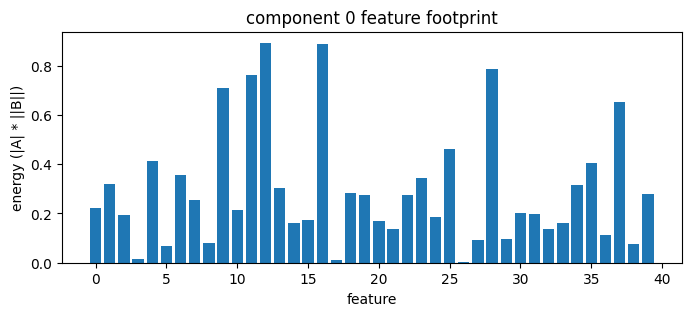

In [10]:
live_idx = torch.nonzero(LIVE).flatten()
assert live_idx.numel() > 0, "no live components; loosen ALIVE_THRESH / MIN_WNORM_FRAC"
# most polysemantic LIVE component = largest feats_served among live -- the SAME rule the
# recursive loop uses (a previous version used conc.argmin here; the two can disagree)
SPLIT_COMP = int(live_idx[nserve[live_idx].argmax()])
print(f"Splitting LIVE component {SPLIT_COMP}: concentration={conc[SPLIT_COMP]:.2f}, "
      f"serves ~{nserve[SPLIT_COMP]:.2f} features, active_rate={float(active_rate[SPLIT_COMP]):.3f}")

# per-feature energy profile -- confirm the chosen component genuinely spreads over features
e = feature_energy(cm, FEATURE_LAYER, SPLIT_COMP).detach()
order = e.argsort(descending=True)
print("top features by energy:", [(int(f), round(float(e[f]), 3)) for f in order[:10]])
plt.figure(figsize=(8, 3)); plt.bar(range(len(e)), e.numpy())
plt.xlabel("feature"); plt.ylabel("energy (|A| * ||B||)")
plt.title(f"component {SPLIT_COMP} feature footprint"); plt.show()

## 6. The split move — diverge the *readers*, not just the writers

Splitting a rank-1 component adds **one new slot**. The key lesson from running this on a real
decomposition: **how you split decides whether carving is even possible.**

- `mode="split"` (50/50 writer): copies the reader `A[:,src]` and splits the writer `B` into
  `B/2 ± delta`. Faithfulness is exact, BUT both children read the *same* features (same `A`), so
  they can't specialise by feature — under the penalty one child simply dies (collapse).
- `mode="partition"` (**default, carve-capable**): splits the reader's *feature footprint* —
  alternating by energy rank so both children get strong features (`A1+A2 = A` exactly, same
  writer `B`). Faithfulness is preserved bit-for-bit while the children start reading
  **disjoint feature sets**. This is the move that actually carves.
- `mode="duplicate"`: full copy (doubles the contribution, perturbs faithfulness) — contrast only.

In all modes the child inherits the parent's **gate parameters** (the MLP weights), not the
importance scores; the scores then diverge (partition) or stay similar (50/50) depending on
whether the readers differ. The copied gate is slightly miscalibrated for the children's new
activation magnitudes — a small but real contributor to why they start weaker and need retraining.

In [14]:
@torch.no_grad()
def _rms(t):
    return t.norm() / math.sqrt(t.numel())
    
@torch.no_grad()
def split_component(cm, layer, src, noise=0.1, mode="partition", init_scale=0.3):
    """Add one new slot PER parent in `src`, dividing (or shadowing) each of them in one call.

    `src` may be a single int or a list of ints (e.g. [0, 1] to split both components of a
    C=2 decomposition in parallel). Each parent is processed independently with the same
    `mode`; all new children are appended after the existing C slots, in the order of `src`.
    Returns the child index (int) if `src` was an int, else the list of child indices
    aligned with `src`: child_of[src[i]] == C_old + i.

    EXACT modes -- the antisymmetric +/-delta keeps child1+child2 == parent, so the summed
    weight (and therefore faithfulness) is preserved bit-for-bit; the delta only breaks the
    permutation symmetry between the children:
      partition          reader support split: A1+A2=A on DISJOINT feature sets, writer B shared
      split_reader5050   A/2+d vs A/2-d (both full support), writer B shared
      split_writer5050   B/2+d vs B/2-d, reader A shared   (alias: "split")
    APPROXIMATE modes -- the sum changes, recon+faith must absorb the shock:
      dupnoiseA    clone A,B; +noise on the child's READER only (footprints differ)
      clone        exact copy, zero noise: symmetry broken ONLY by independent mask draws
      dupnoiseB    clone A,B; +noise on the child's WRITER only (readers stay identical)
      dummy        fresh random component at init_scale, parent untouched (role transfer)
    `noise` is RELATIVE: delta = noise * rms(parent tensor) * randn -- scale-free, unlike the
    old absolute 0.1 which silently assumed O(1) weights."""
    srcs = [src] if isinstance(src, int) else list(src)
    assert len(set(srcs)) == len(srcs), "duplicate indices in src: each parent can be split once per call"
    comp = module_maps(cm)[0][layer]; gate = module_maps(cm)[1][layer]
    A, B = comp.A.data, comp.B.data
    C_old = A.shape[1]
    assert all(0 <= s < C_old for s in srcs), f"src indices must be < C={C_old}"
    new_As, new_Bs = [], []
    for s in srcs:
        a, b = A[:, s].clone(), B[s].clone()   # CLONE: A[:, s] / B[s] are views, and the
        # exact modes write the parent slot in place before building the sibling -- without
        # the clone the sibling would be built from the already-mutated parent (breaks exactness)
        if mode == "partition":
            order = torch.argsort(a.abs(), descending=True)
            A1 = torch.zeros_like(a); A1[order[0::2]] = a[order[0::2]]
            A2 = torch.zeros_like(a); A2[order[1::2]] = a[order[1::2]]
            A[:, s] = A1; new_A = A2.unsqueeze(1); new_B = b.unsqueeze(0).clone()
        elif mode == "split_reader5050":
            d = noise * _rms(a) * torch.randn_like(a)
            A[:, s] = a / 2 + d
            new_A = (a / 2 - d).unsqueeze(1); new_B = b.unsqueeze(0).clone()
        elif mode in ("split_writer5050", "split"):
            d = noise * _rms(b) * torch.randn_like(b)
            B[s] = b / 2 + d
            new_B = (b / 2 - d).unsqueeze(0); new_A = a.unsqueeze(1).clone()
        elif mode == "dupnoiseA":
            new_A = a.unsqueeze(1).clone() + noise * _rms(a) * torch.randn_like(a.unsqueeze(1))
            new_B = b.unsqueeze(0).clone()
        elif mode == "clone":
            new_A = a.unsqueeze(1).clone(); new_B = b.unsqueeze(0).clone()
        elif mode == "dupnoiseB":
            new_A = a.unsqueeze(1).clone()
            new_B = b.unsqueeze(0).clone() + noise * _rms(b) * torch.randn_like(b.unsqueeze(0))
        elif mode == "dummy":
            new_A = init_scale * _rms(a) * torch.randn(A.shape[0], 1, device=A.device)
            new_B = init_scale * _rms(b) * torch.randn(1, B.shape[1], device=B.device)
        else:
            raise ValueError(f"unknown mode {mode}")
        new_As.append(new_A); new_Bs.append(new_B)
    comp.A = nn.Parameter(torch.cat([A] + new_As, dim=1))
    comp.B = nn.Parameter(torch.cat([B] + new_Bs, dim=0))
    comp.C += len(srcs)
    if isinstance(gate, Gate):
        gate.weight = nn.Parameter(torch.cat([gate.weight.data] + [gate.weight.data[s:s+1].clone() for s in srcs]))
        gate.bias   = nn.Parameter(torch.cat([gate.bias.data]   + [gate.bias.data[s:s+1].clone()   for s in srcs]))
    else:
        for nm in ["mlp_in", "in_bias", "mlp_out", "out_bias"]:
            w = getattr(gate, nm).data
            setattr(gate, nm, nn.Parameter(torch.cat([w] + [w[s:s+1].clone() for s in srcs], dim=0)))
    children = list(range(C_old, C_old + len(srcs)))
    return children[0] if isinstance(src, int) else children

## 7. How to read the outcome (carve vs collapse)

After splitting and retraining we look at the two children: **active rate** (vs the single
`ALIVE_THRESH`), the **feature each reads**, the **reading concentration**, and the **overlap**
(Jaccard) of their active-input sets. The classifier:

- **COLLAPSE** — at most one child alive.
- **CARVE (monosemantic)** — different preferred features, overlap `< CARVE_OVERLAP_MAX` (0.15),
  and both children concentrated (`read_conc > MONO_CONC`).
- **PARTIAL CARVE** — different features, overlap `< PARTIAL_OVERLAP_MAX` (0.4), **and** genuine
  feature reduction: max child `feats_served < FEATS_REDUCED_FRAC ×` parent. The reduction
  requirement is what catches the near-death mirage (very sparse children with low overlap but
  no actual carving).
- **REDUNDANT / smear** — otherwise.

In [16]:
@torch.no_grad()
def analyze_children(cm, layer, children, n_features, feat_p, parent_nserve, tau=TAU):
    x = sample_batch(n_features, feat_p, bs=4096)
    ci, _, _ = causal_importances(cm, x)
    g = ci[layer]
    rows, on = [], []
    for c in children:
        active = g[:, c] > tau; on.append(active)
        e = feature_energy(cm, layer, c)                     # amplitude convention (see cell 4)
        tot = e.sum().clamp_min(1e-12)
        rows.append(dict(comp=c, active_rate=float(active.float().mean()),
                         pref_feat=int(e.argmax()),
                         read_conc=float(e.max() / tot),
                         feats_served=float(tot ** 2 / (e ** 2).sum().clamp_min(1e-12))))
    inter = (on[0] & on[1]).float().sum(); union = (on[0] | on[1]).float().sum().clamp_min(1)
    overlap = float(inter / union)
    alive = [r["active_rate"] > ALIVE_THRESH for r in rows]  # the ONE alive threshold
    diff = rows[0]["pref_feat"] != rows[1]["pref_feat"]
    reduced = max(r["feats_served"] for r in rows) < FEATS_REDUCED_FRAC * parent_nserve
    if sum(alive) <= 1:
        outcome = "COLLAPSE (a child died)"
    elif diff and overlap < CARVE_OVERLAP_MAX and all(r["read_conc"] > MONO_CONC for r in rows):
        outcome = "CARVE (monosemantic)"                # both children read ~one feature
    elif diff and overlap < PARTIAL_OVERLAP_MAX and reduced:
        outcome = "PARTIAL CARVE (polysem. reduced)"    # success: each child serves fewer features
    else:
        outcome = "REDUNDANT / smear"
    return rows, overlap, outcome

## 8. Sweep `p`: split the same component, retrain at each `p`, compare

For each `p` we start from a **fresh copy** of the loaded decomposition (so every run sees the
same starting point), split the chosen component, retrain to convergence, and record the outcome.
The pre-retrain aliveness print is the control that separates "the split move failed" from "the
retrain dynamics killed the children".

In [23]:
results = []
SPLIT_MODE = "dummy"
SPLIT_COMPS = [0, 1]
IMPORTANCE_MINIMALITY_COEFF = 2e-4
for p in P_VALUES:
    cm_p = copy.deepcopy(cm)                       # fresh start per p
    children = split_component(cm_p, FEATURE_LAYER, SPLIT_COMPS, mode=SPLIT_MODE)
    pairs = list(zip(SPLIT_COMPS, children))       # [(parent, its child), ...]
    touched = SPLIT_COMPS + children               # every slot involved in the surgery
    # PROOF the split itself works: children should be ALIVE here, before any retraining
    for s, c in pairs:
        pre_rows, _, _ = analyze_children(cm_p, FEATURE_LAYER, [s, c], N_FEATURES, FEAT_P, float(nserve[s]))
        print(f"p={p:>4} comp {s}: pre-retrain child_active={[round(r['active_rate'],3) for r in pre_rows]} "
              f"(if these are >0 but die below, it's the RETRAIN, not the split)")
    # ONE retrain for all pairs simultaneously; freeze protects the union of parents+children
    # (with C=2 -> 4 this covers every slot, i.e. it is equivalent to freeze_keep=None)
    continue_train(cm_p, N_FEATURES, FEAT_P, steps=RETRAIN_STEPS, p_norm=p,
                   freeze_keep=(FEATURE_LAYER, touched) if FREEZE_OTHERS else None,
                   warmup_frac=MINIMALITY_WARMUP,
                   monitor=(FEATURE_LAYER, touched) if MONITOR_SPLIT else None)
    for s, c in pairs:
        rows, overlap, outcome = analyze_children(cm_p, FEATURE_LAYER, [s, c], N_FEATURES, FEAT_P, float(nserve[s]))
        results.append(dict(p=p, parent=s, child=c, outcome=outcome, overlap=overlap,
                            faith_after=faithfulness_mse(cm_p),
                            active=[round(r["active_rate"], 3) for r in rows],
                            feat=[r["pref_feat"] for r in rows],
                            conc=[round(r["read_conc"], 2) for r in rows],
                            child_feats_served=[round(r["feats_served"], 1) for r in rows]))
        print(f"p={p:>4} comp {s}: {outcome:24s} active={results[-1]['active']} "
              f"feat={results[-1]['feat']} feats_served(parent~{nserve[s]:.1f})->{results[-1]['child_feats_served']} "
              f"overlap={overlap:.2f} faith={results[-1]['faith_after']:.2e}")

p= 0.7 comp 0: pre-retrain child_active=[0.369, 0.055] (if these are >0 but die below, it's the RETRAIN, not the split)
p= 0.7 comp 1: pre-retrain child_active=[0.449, 0.1] (if these are >0 but die below, it's the RETRAIN, not the split)
      [monitor] step     0 child_active=[0.387, 0.472, 0.046, 0.087] (coeff_t=0.0e+00 stoch=0.0111 faith=1.01e-01)
      [monitor] step   250 child_active=[0.653, 1.0, 1.0, 1.0] (coeff_t=1.3e-05 stoch=0.0109 faith=8.82e-02)
      [monitor] step   500 child_active=[0.574, 0.639, 1.0, 1.0] (coeff_t=2.0e-05 stoch=0.0111 faith=8.81e-02)
      [monitor] step   750 child_active=[0.548, 0.602, 0.672, 0.577] (coeff_t=2.0e-05 stoch=0.0102 faith=8.81e-02)
      [monitor] step  1000 child_active=[0.537, 0.61, 0.641, 0.529] (coeff_t=2.0e-05 stoch=0.0107 faith=8.81e-02)
      [monitor] step  1250 child_active=[0.532, 0.588, 0.658, 0.55] (coeff_t=2.0e-05 stoch=0.0108 faith=8.80e-02)
      [monitor] step  1500 child_active=[0.503, 0.583, 0.638, 0.531] (coeff_t=2.0e-0

## 10. Results

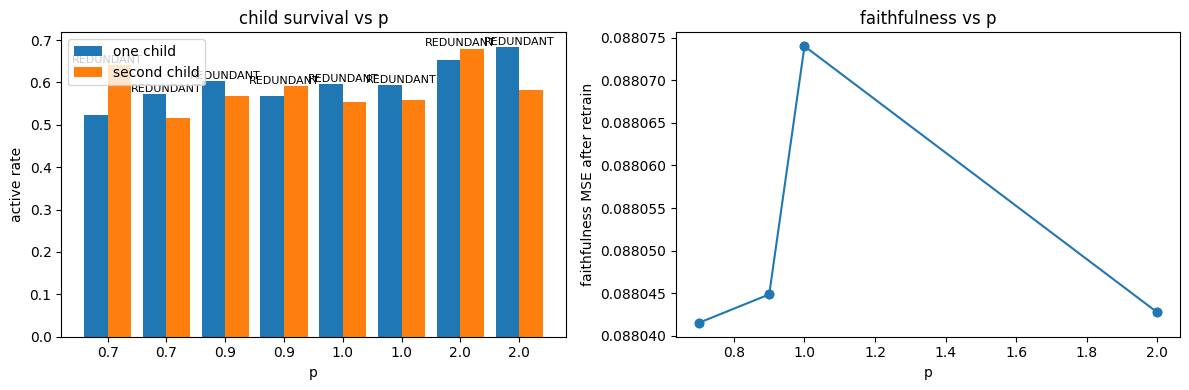

,p,parent,child,outcome,overlap,faith_after,active,feat,conc,child_feats_served
0,0.7,0,2,REDUNDANT / smear,0.566929,0.088042,"[0.524, 0.642]","[11, 29]","[0.07, 0.06]","[23.7, 24.9]"
1,0.7,1,3,REDUNDANT / smear,0.563222,0.088042,"[0.573, 0.516]","[5, 24]","[0.08, 0.07]","[23.2, 22.9]"
2,0.9,0,2,REDUNDANT / smear,0.603805,0.088045,"[0.604, 0.569]","[16, 14]","[0.07, 0.08]","[24.0, 24.9]"
3,0.9,1,3,REDUNDANT / smear,0.624445,0.088045,"[0.569, 0.592]","[5, 23]","[0.08, 0.07]","[23.7, 26.2]"
4,1.0,0,2,REDUNDANT / smear,0.603607,0.088074,"[0.596, 0.554]","[12, 21]","[0.08, 0.07]","[25.1, 23.9]"
5,1.0,1,3,REDUNDANT / smear,0.580288,0.088074,"[0.593, 0.558]","[5, 10]","[0.08, 0.07]","[22.9, 24.4]"
6,2.0,0,2,REDUNDANT / smear,0.672699,0.088043,"[0.652, 0.68]","[12, 19]","[0.08, 0.08]","[24.1, 22.8]"
7,2.0,1,3,REDUNDANT / smear,0.622771,0.088043,"[0.684, 0.583]","[5, 24]","[0.08, 0.07]","[23.0, 25.9]"


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ps = [r["p"] for r in results]
c0 = [r["active"][0] for r in results]; c1 = [r["active"][1] for r in results]
x = np.arange(len(ps))
ax[0].bar(x - 0.2, c0, 0.4, label="one child"); ax[0].bar(x + 0.2, c1, 0.4, label="second child")
ax[0].set_xticks(x); ax[0].set_xticklabels(ps); ax[0].set_xlabel("p"); ax[0].set_ylabel("active rate")
ax[0].set_title("child survival vs p"); ax[0].legend()
for i, r in enumerate(results):
    ax[0].text(i, max(c0[i], c1[i]) + 0.005, r["outcome"].split()[0], ha="center", fontsize=8)
ax[1].plot(ps, [r["faith_after"] for r in results], "o-")
ax[1].set_xlabel("p"); ax[1].set_ylabel("faithfulness MSE after retrain"); ax[1].set_title("faithfulness vs p")
plt.tight_layout(); plt.show()

import pandas as pd
pd.DataFrame(results)

## 11. What we learned

Findings from running this on the real C=20 TMS40-10 decomposition (pre-cleanup version of this
notebook; re-run to confirm under the unified thresholds and the added layerwise term):

1. **The split move must diverge the readers.** A 50/50 *writer* split copies `A`, so both children
   read the same features and one dies. The **partition** split keeps both alive and each serves
   ~half as many features — on component 7, features-served went ~14 → ~[6, 6.7], inputs nearly
   disjoint, faithfulness preserved.
2. `p` behaves monotonically: 0.7 → overlap 0.19, 0.9 → 0.23, 1.0 → 0.24, 2.0 → 0.40.
   More concave = sharper carve.
3. `coeff = 2e-5`, `p = 0.7` is the clean-carve operating point; well above it the minimality
   penalty kills the children during retrain.

## 12. Iterative splitting — drive toward monosemantic

One split halves a component's polysemanticity (14 → ~7). To keep going, we **iterate**: each
round, re-scan the LIVE components, pick the **most polysemantic** one (largest `feats_served`),
split it, retrain at the operating point (`coeff=2e-5`, `p=0.7`, freeze-others + warmup), and
repeat — stopping when the worst live component is ~monosemantic (`feats_served <= MONO_THRESH`)
or after `REC_MAX_ROUNDS`. The split `mode` is an **explicit argument recorded in every history
row**, so partition and duplicate runs can never be confused after the fact.

The loop is **greedy / breadth-first**: it always attacks the worst offender, so it spreads across
components before coming back to split the children. Reaching full monosemanticity for 40 features
needs ~27 splits (13 live → ~40); `REC_MAX_ROUNDS` caps it for a tractable run.

In [30]:
REC_COEFF      = 2e-5     # highest coeff below your death threshold (from the sweep)
REC_P          = 0.7      # most concave surviving p -> sharpest carve
REC_STEPS      = 1500     # retrain steps per split (lower than 2000 so many rounds stay tractable)
REC_MAX_ROUNDS = 50       # cap; a true safety limit now that success/exhaustion exits can fire
MONO_THRESH    = 2.5      # ~monosemantic under the AMPLITUDE convention: the cleanly mono
                          # components (14, 18: conc ~0.7) read as feats_served=2.0, so the old
                          # 1.5 was unreachable and the success exit could never fire
SPLIT_MIN_ACTIVE  = 0.1   # selection gate: only components firing on >10% of inputs are split
                          # candidates -- near-dead smear has noise-inflated feats_served (the
                          # ghost-ratio artifact) and would otherwise capture the argmax forever
REPORT_MIN_ACTIVE = 0.1   # final-report filter: ghost debris above ALIVE_THRESH but below this
                          # is listed separately, not mixed into the headline feats_served

def iterative_split(cm, feature_layer=FEATURE_LAYER, mode="partition", coeff=REC_COEFF, p=REC_P,
                    steps=REC_STEPS, max_rounds=REC_MAX_ROUNDS, mono_thresh=MONO_THRESH,
                    warmup=MINIMALITY_WARMUP, freeze=True, log=True):
    """Greedy loop: split the most polysemantic HEALTHY component, retrain, repeat.
    Selection is gated (active_rate > SPLIT_MIN_ACTIVE) and failed lineages are blacklisted
    (parent AND child banned after a non-carve outcome), so the loop cannot rathole on ghosts
    or stubborn cores. Exits: (1) success -- every candidate ~monosemantic; (2) exhaustion --
    every candidate banned; (3) max_rounds safety cap. `mode` is explicit and recorded."""
    cm = copy.deepcopy(cm)            # work on a copy so the loaded model is preserved
    history = []
    banned = set()                    # failed lineages: never re-targeted (a failed parent's
                                      # child inherits the entangled/ghost structure)
    stop_reason = f"max_rounds cap ({max_rounds}) reached"
    for rnd in range(max_rounds):
        conc, nserve = feature_concentration(cm, feature_layer)
        active_rate, wnorm = component_stats(cm, feature_layer, N_FEATURES, FEAT_P)
        live = live_mask(active_rate, wnorm); live_idx = torch.nonzero(live).flatten()
        n_live = int(live.sum())
        # candidates: live, healthy enough to trust feats_served, and not blacklisted
        cand = [int(i) for i in live_idx
                if float(active_rate[i]) > SPLIT_MIN_ACTIVE and int(i) not in banned]
        if not cand:
            stop_reason = (f"no candidates left: {n_live} live, banned={sorted(banned)}")
            break
        worst = max(cand, key=lambda i: float(nserve[i]))    # most polysemantic candidate
        worst_served = float(nserve[worst])
        if worst_served <= mono_thresh:
            stop_reason = (f"SUCCESS: all {len(cand)} candidates ~monosemantic "
                           f"(max feats={worst_served:.1f} <= {mono_thresh})")
            break
        child = split_component(cm, feature_layer, worst, mode=mode)
        continue_train(cm, N_FEATURES, FEAT_P, steps=steps, p_norm=p, imp_coeff=coeff,
                       freeze_keep=(feature_layer, [worst, child]) if freeze else None,
                       warmup_frac=warmup, monitor=None)
        rows, overlap, outcome = analyze_children(cm, feature_layer, [worst, child],
                                                  N_FEATURES, FEAT_P, worst_served)
        a = [round(r["active_rate"], 3) for r in rows]
        # feats from the SAME analysis as the outcome; nan for a dead child rather than the
        # ghost-ratio number (a dead component's footprint participation ratio is noise)
        fs = [round(r["feats_served"], 1) if r["active_rate"] > ALIVE_THRESH else float("nan")
              for r in rows]
        alive = min(r["active_rate"] for r in rows) > ALIVE_THRESH   # same threshold as everywhere
        if "CARVE" not in outcome:
            banned.add(worst); banned.add(child)             # retire the whole lineage
        history.append(dict(round=rnd, mode=mode, split=worst, parent_feats=round(worst_served, 1),
                            child_feats=fs, active=a, overlap=round(overlap, 2),
                            alive=alive, outcome=outcome, n_live_before=n_live))
        if log: print(f"round {rnd}: split comp {worst} (feats {worst_served:.1f}) -> children {fs} "
                      f"active={a} overlap={overlap:.2f} alive={alive} {outcome} | live_before={n_live}")
    # final state: report healthy components and ghost debris separately
    conc, nserve = feature_concentration(cm, feature_layer)
    active_rate, wnorm = component_stats(cm, feature_layer, N_FEATURES, FEAT_P)
    live = live_mask(active_rate, wnorm); live_idx = torch.nonzero(live).flatten()
    healthy = [i for i in live_idx.tolist() if float(active_rate[i]) > REPORT_MIN_ACTIVE]
    ghosts  = [i for i in live_idx.tolist() if float(active_rate[i]) <= REPORT_MIN_ACTIVE]
    live_feats = sorted([float(nserve[i]) for i in healthy], reverse=True)
    if log:
        print(f"\nSTOP: {stop_reason}")
        print(f"FINAL: {len(healthy)} healthy live components"
              f" (+{len(ghosts)} ghost/near-dead excluded from summary: {ghosts})")
        print(f"  feats_served = {[round(f,1) for f in live_feats]}")
        print(f"  {sum(1 for f in live_feats if f <= mono_thresh)}/{len(live_feats)} "
              f"~monosemantic (<= {mono_thresh})")
        if banned: print(f"  banned lineages (failed splits, irreducibility candidates): {sorted(banned)}")
    return cm, history, live_feats

round 0: split comp 0 (feats 24.3) -> children [24.3, 26.0] active=[0.59, 0.562] overlap=0.57 alive=True REDUNDANT / smear | live_before=2
round 1: split comp 2 (feats 26.0) -> children [26.2, 26.4] active=[0.587, 0.637] overlap=0.62 alive=True REDUNDANT / smear | live_before=3
round 2: split comp 3 (feats 26.4) -> children [26.0, 24.8] active=[0.582, 0.576] overlap=0.58 alive=True REDUNDANT / smear | live_before=4
round 3: split comp 2 (feats 26.2) -> children [27.7, 27.3] active=[0.667, 0.654] overlap=0.69 alive=True REDUNDANT / smear | live_before=5
round 4: split comp 2 (feats 27.7) -> children [28.1, 24.3] active=[0.659, 0.615] overlap=0.66 alive=True REDUNDANT / smear | live_before=6
round 5: split comp 2 (feats 28.1) -> children [27.6, 23.9] active=[0.644, 0.556] overlap=0.59 alive=True REDUNDANT / smear | live_before=7
round 6: split comp 2 (feats 27.6) -> children [26.0, 30.3] active=[0.614, 0.626] overlap=0.60 alive=True REDUNDANT / smear | live_before=8
round 7: split comp 8

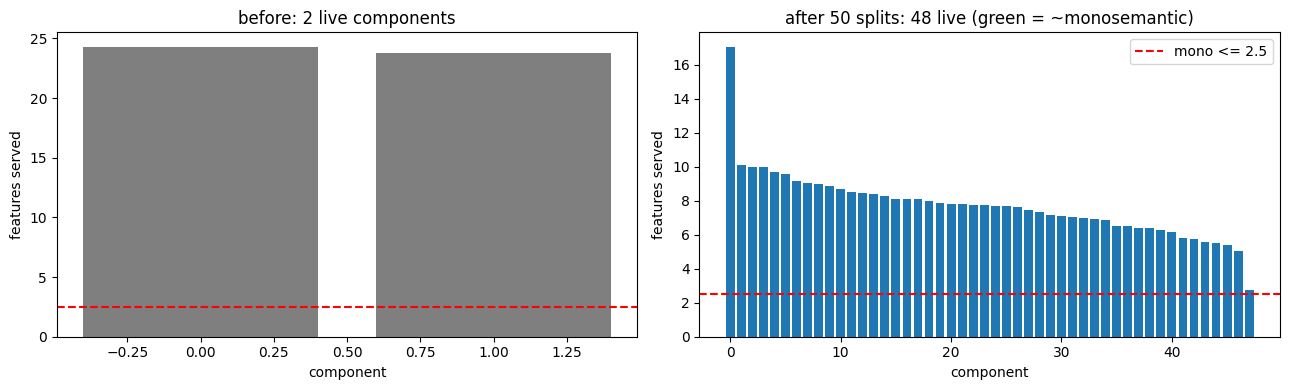

,round,mode,split,parent_feats,child_feats,active,overlap,alive,outcome,n_live_before
0,0,partition,0,24.3,"[24.3, 26.0]","[0.59, 0.562]",0.57,True,REDUNDANT / smear,2
1,1,partition,2,26.0,"[26.2, 26.4]","[0.587, 0.637]",0.62,True,REDUNDANT / smear,3
2,2,partition,3,26.4,"[26.0, 24.8]","[0.582, 0.576]",0.58,True,REDUNDANT / smear,4
3,3,partition,2,26.2,"[27.7, 27.3]","[0.667, 0.654]",0.69,True,REDUNDANT / smear,5
4,4,partition,2,27.7,"[28.1, 24.3]","[0.659, 0.615]",0.66,True,REDUNDANT / smear,6
5,5,partition,2,28.1,"[27.6, 23.9]","[0.644, 0.556]",0.59,True,REDUNDANT / smear,7
6,6,partition,2,27.6,"[26.0, 30.3]","[0.614, 0.626]",0.60,True,REDUNDANT / smear,8
7,7,partition,8,30.3,"[25.9, 24.9]","[0.582, 0.569]",0.55,True,REDUNDANT / smear,9
8,8,partition,5,27.3,"[16.2, 17.1]","[0.407, 0.37]",0.28,True,PARTIAL CARVE (polysem. reduced),10
9,9,partition,2,26.0,"[14.1, 15.4]","[0.413, 0.395]",0.26,True,PARTIAL CARVE (polysem. reduced),11


In [32]:
cm_rec, rec_history, rec_live_feats = recursive_split(cm, mode="partition")

# feats_served of the live components before vs after recursion
_, nserve0 = feature_concentration(cm, FEATURE_LAYER)
ar0, wn0 = component_stats(cm, FEATURE_LAYER, N_FEATURES, FEAT_P)
before = sorted([float(nserve0[i]) for i in torch.nonzero(live_mask(ar0, wn0)).flatten()], reverse=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(len(before)), before, color="tab:gray"); ax[0].axhline(MONO_THRESH, color="r", ls="--")
ax[0].set_title(f"before: {len(before)} live components"); ax[0].set_xlabel("component"); ax[0].set_ylabel("features served")
colors = ["tab:green" if f <= MONO_THRESH else "tab:blue" for f in rec_live_feats]
ax[1].bar(range(len(rec_live_feats)), rec_live_feats, color=colors); ax[1].axhline(MONO_THRESH, color="r", ls="--", label=f"mono <= {MONO_THRESH}")
ax[1].set_title(f"after {len(rec_history)} splits: {len(rec_live_feats)} live (green = ~monosemantic)")
ax[1].set_xlabel("component"); ax[1].set_ylabel("features served"); ax[1].legend()
plt.tight_layout(); plt.show()

import pandas as pd
pd.DataFrame(rec_history)

In [ ]:
cm_rec, rec_history, rec_live_feats = recursive_split(cm, mode="dummy")

# feats_served of the live components before vs after recursion
_, nserve0 = feature_concentration(cm, FEATURE_LAYER)
ar0, wn0 = component_stats(cm, FEATURE_LAYER, N_FEATURES, FEAT_P)
before = sorted([float(nserve0[i]) for i in torch.nonzero(live_mask(ar0, wn0)).flatten()], reverse=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(len(before)), before, color="tab:gray"); ax[0].axhline(MONO_THRESH, color="r", ls="--")
ax[0].set_title(f"before: {len(before)} live components"); ax[0].set_xlabel("component"); ax[0].set_ylabel("features served")
colors = ["tab:green" if f <= MONO_THRESH else "tab:blue" for f in rec_live_feats]
ax[1].bar(range(len(rec_live_feats)), rec_live_feats, color=colors); ax[1].axhline(MONO_THRESH, color="r", ls="--", label=f"mono <= {MONO_THRESH}")
ax[1].set_title(f"after {len(rec_history)} splits: {len(rec_live_feats)} live (green = ~monosemantic)")
ax[1].set_xlabel("component"); ax[1].set_ylabel("features served"); ax[1].legend()
plt.tight_layout(); plt.show()

import pandas as pd
pd.DataFrame(rec_history)

round 0: split comp 0 (feats 24.3) -> children [24.1, 23.0] active=[0.504, 0.601] overlap=0.55 alive=True REDUNDANT / smear | live_before=2
round 1: split comp 0 (feats 24.1) -> children [24.2, 25.1] active=[0.573, 0.598] overlap=0.62 alive=True REDUNDANT / smear | live_before=3
round 2: split comp 3 (feats 25.1) -> children [26.0, 27.0] active=[0.614, 0.581] overlap=0.63 alive=True REDUNDANT / smear | live_before=4
round 3: split comp 4 (feats 27.0) -> children [27.1, 24.0] active=[0.604, 0.578] overlap=0.61 alive=True REDUNDANT / smear | live_before=5
round 4: split comp 4 (feats 27.1) -> children [26.5, 26.4] active=[0.615, 0.569] overlap=0.59 alive=True REDUNDANT / smear | live_before=6
round 5: split comp 4 (feats 26.5) -> children [25.5, 24.8] active=[0.613, 0.555] overlap=0.58 alive=True REDUNDANT / smear | live_before=7
round 6: split comp 6 (feats 26.4) -> children [26.6, 26.2] active=[0.596, 0.593] overlap=0.63 alive=True REDUNDANT / smear | live_before=8
round 7: split comp 

KeyboardInterrupt: 